In [1]:
import pandas as pd
from pathlib import Path

print("ShopSphere EDA Started!")

DATA_PATH = Path("../data/processed")

customers = pd.read_csv(DATA_PATH / "customers_clean.csv")
products = pd.read_csv(DATA_PATH / "products_clean.csv")
orders = pd.read_csv(DATA_PATH / "orders_clean.csv")
order_items = pd.read_csv(DATA_PATH / "order_items_clean.csv")
payments = pd.read_csv(DATA_PATH / "payments_clean.csv")

orders["order_date"] = pd.to_datetime(orders["order_date"])
payments["payment_date"] = pd.to_datetime(payments["payment_date"])

print("All cleaned datasets loaded successfully!")

ShopSphere EDA Started!
All cleaned datasets loaded successfully!


In [2]:
datasets = {
    "Customers": customers,
    "Products": products,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 40)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])


Customers
----------------------------------------
Rows: 20000
Columns: 10

Products
----------------------------------------
Rows: 1000
Columns: 10

Orders
----------------------------------------
Rows: 100000
Columns: 5

Order Items
----------------------------------------
Rows: 300323
Columns: 5

Payments
----------------------------------------
Rows: 100000
Columns: 6


In [3]:
print("PRODUCT ANALYSIS")
print("=" * 50)

print("\nProducts by Category:")
print(products["category"].value_counts())

print("\nProducts by Brand:")
print(products["brand"].value_counts().head(10))

PRODUCT ANALYSIS

Products by Category:
category
Sports & Fitness          176
Home & Kitchen            175
Beauty & Personal Care    173
Books                     169
Electronics               162
Fashion                   145
Name: count, dtype: int64

Products by Brand:
brand
RunX              46
DermaCare         42
UrbanHome         42
KnowledgeHouse    40
AuraBeauty        39
FitCore           38
KitchenPro        36
HomeNest          36
LearnPress        36
InsightBooks      35
Name: count, dtype: int64


In [4]:
print("ORDER STATUS ANALYSIS")
print("=" * 50)

status_counts = orders["order_status"].value_counts()

print(status_counts)

print("\nPercentage:")
print(
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

ORDER STATUS ANALYSIS
order_status
Delivered     71869
Shipped       10056
Processing     8104
Cancelled      5019
Returned       4952
Name: count, dtype: int64

Percentage:
order_status
Delivered     71.87
Shipped       10.06
Processing     8.10
Cancelled      5.02
Returned       4.95
Name: proportion, dtype: float64


In [5]:
print("SALES CHANNEL ANALYSIS")
print("=" * 50)

print(orders["sales_channel"].value_counts())

print("\nPercentage:")
print(
    orders["sales_channel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

SALES CHANNEL ANALYSIS
sales_channel
Website        44992
Mobile App     39918
Marketplace    15090
Name: count, dtype: int64

Percentage:
sales_channel
Website        44.99
Mobile App     39.92
Marketplace    15.09
Name: proportion, dtype: float64


In [6]:
# ==========================================
# 26. REVENUE CALCULATION
# ==========================================

order_items["gross_amount"] = (
    order_items["quantity"] * order_items["unit_price"]
)

order_items["discount_amount"] = (
    order_items["gross_amount"] *
    order_items["discount_pct"] / 100
)

order_items["net_amount"] = (
    order_items["gross_amount"] -
    order_items["discount_amount"]
)

print("Revenue columns created successfully!")

print(order_items[
    [
        "quantity",
        "unit_price",
        "discount_pct",
        "gross_amount",
        "discount_amount",
        "net_amount"
    ]
].head())

Revenue columns created successfully!
   quantity  unit_price  discount_pct  gross_amount  discount_amount  \
0         2      5800.0             0       11600.0              0.0   
1         2      4150.0            20        8300.0           1660.0   
2         1      7650.0             5        7650.0            382.5   
3         1      9340.0            10        9340.0            934.0   
4         1      7030.0            10        7030.0            703.0   

   net_amount  
0     11600.0  
1      6640.0  
2      7267.5  
3      8406.0  
4      6327.0  


In [7]:
# ==========================================
# 27. BUSINESS KPIs
# ==========================================

total_orders = orders["order_id"].nunique()
total_customers = customers["customer_id"].nunique()
total_products = products["product_id"].nunique()

total_quantity = order_items["quantity"].sum()
gross_revenue = order_items["gross_amount"].sum()
total_discount = order_items["discount_amount"].sum()
net_revenue = order_items["net_amount"].sum()

average_order_value = net_revenue / total_orders

print("SHOPSPHERE BUSINESS KPIs")
print("=" * 50)

print(f"Total Customers      : {total_customers:,}")
print(f"Total Products       : {total_products:,}")
print(f"Total Orders         : {total_orders:,}")
print(f"Total Quantity Sold  : {total_quantity:,}")
print(f"Gross Revenue        : ₹{gross_revenue:,.2f}")
print(f"Total Discount       : ₹{total_discount:,.2f}")
print(f"Net Revenue          : ₹{net_revenue:,.2f}")
print(f"Average Order Value  : ₹{average_order_value:,.2f}")

SHOPSPHERE BUSINESS KPIs
Total Customers      : 20,000
Total Products       : 1,000
Total Orders         : 100,000
Total Quantity Sold  : 453,792
Gross Revenue        : ₹5,500,518,680.00
Total Discount       : ₹447,192,433.00
Net Revenue          : ₹5,053,326,247.00
Average Order Value  : ₹50,533.26


In [8]:
# ==========================================
# 28. MONTHLY REVENUE TREND
# ==========================================

order_items["order_date"] = order_items["order_id"].map(
    orders.set_index("order_id")["order_date"]
)

monthly_revenue = (
    order_items
    .assign(month=order_items["order_date"].dt.to_period("M"))
    .groupby("month")["net_amount"]
    .sum()
    .reset_index()
)

monthly_revenue["month"] = monthly_revenue["month"].astype(str)

print(monthly_revenue)

      month   net_amount
0   2024-01    4641715.5
1   2024-02   14761870.0
2   2024-03   24591809.0
3   2024-04   36060049.0
4   2024-05   42423134.5
5   2024-06   57602367.0
6   2024-07   67806903.5
7   2024-08   83196670.5
8   2024-09   97983192.0
9   2024-10  106871623.0
10  2024-11  120017938.0
11  2024-12  137410058.0
12  2025-01  157956004.0
13  2025-02  157080749.5
14  2025-03  202105843.5
15  2025-04  215390161.5
16  2025-05  243467780.5
17  2025-06  275480030.0
18  2025-07  309825646.5
19  2025-08  361827502.5
20  2025-09  401626723.0
21  2025-10  481719446.5
22  2025-11  586234397.5
23  2025-12  867244632.0


In [9]:
# ==========================================
# 29. TOP 10 PRODUCTS
# ==========================================

product_sales = (
    order_items
    .groupby("product_id")
    .agg(
        quantity_sold=("quantity", "sum"),
        revenue=("net_amount", "sum")
    )
    .reset_index()
)

product_sales = product_sales.merge(
    products[["product_id", "product_name", "category", "brand"]],
    on="product_id",
    how="left"
)

top_products = product_sales.sort_values(
    "revenue",
    ascending=False
).head(10)

print(top_products)

    product_id  quantity_sold     revenue                    product_name  \
491     P00492            516  38004435.0   ZenByte Advanced Smartwatches   
120     P00121            529  36758592.5       ZenByte Ultra Accessories   
272     P00273            483  35280725.0        Voltix Elite Smartphones   
519     P00520            482  34894532.0            Voltix Elite Laptops   
621     P00622            492  34746720.0       NovaTech Smart Headphones   
116     P00117            468  33899570.0      PixelPro Ultra Smartphones   
507     P00508            495  33857696.0  PixelPro Advanced Smartwatches   
59      P00060            474  33130860.0     Voltix Advanced Smartphones   
729     P00730            488  33047644.0      ZenByte Elite Smartwatches   
78      P00079            465  32884551.0          TechSphere Pro Laptops   

        category       brand  
491  Electronics     ZenByte  
120  Electronics     ZenByte  
272  Electronics      Voltix  
519  Electronics      Voltix

In [10]:
# ==========================================
# 30. CATEGORY PERFORMANCE
# ==========================================

category_sales = (
    product_sales
    .groupby("category")
    .agg(
        quantity_sold=("quantity_sold", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
)

print(category_sales)

                        quantity_sold       revenue
category                                           
Electronics                     73042  2.786280e+09
Home & Kitchen                  79105  9.847658e+08
Sports & Fitness                80393  7.353971e+08
Fashion                         65322  2.455206e+08
Beauty & Personal Care          79139  2.090514e+08
Books                           76791  9.231105e+07


In [11]:
# ==========================================
# 31. SALES CHANNEL REVENUE
# ==========================================

order_items_channel = order_items.merge(
    orders[["order_id", "sales_channel"]],
    on="order_id",
    how="left"
)

channel_sales = (
    order_items_channel
    .groupby("sales_channel")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("net_amount", "sum"),
        quantity_sold=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
)

print(channel_sales)

               orders       revenue  quantity_sold
sales_channel                                     
Website         44992  2.275800e+09         204804
Mobile App      39918  2.025496e+09         181187
Marketplace     15090  7.520300e+08          67801


In [12]:
# ==========================================
# 32. CUSTOMER ANALYSIS
# ==========================================

customer_sales = (
    order_items.merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .groupby("customer_id")
    .agg(
        orders=("order_id", "nunique"),
        quantity_sold=("quantity", "sum"),
        revenue=("net_amount", "sum")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

print("TOP 10 CUSTOMERS")
print(customer_sales.head(10))

TOP 10 CUSTOMERS
      customer_id  orders  quantity_sold    revenue
2140       C02155       6             43  1280758.0
18039      C18159       9             47  1262494.0
18271      C18392       9             50  1235714.5
10852      C10921      12             58  1184067.0
15834      C15937      13             65  1152215.5
17887      C18005      11             74  1148593.0
1697       C01709       9             59  1138679.0
13040      C13126      10             55  1133612.0
14214      C14303      12             57  1127122.5
11523      C11594       6             42  1122519.5


In [13]:
# ==========================================
# 33. PAYMENT ANALYSIS
# ==========================================

payment_summary = (
    payments
    .groupby("payment_status")
    .agg(
        transactions=("payment_id", "count"),
        total_value=("payment_amount", "sum"),
        average_value=("payment_amount", "mean")
    )
)

print(payment_summary)

                transactions   total_value  average_value
payment_status                                           
Failed                  4213  0.000000e+00       0.000000
Refunded                8458  4.201404e+08   49673.730728
Successful             87329  4.422003e+09   50636.136724


In [14]:
# ==========================================
# 34. PAYMENT SUCCESS RATE
# ==========================================

successful = (
    payments["payment_status"] == "Successful"
).sum()

total_payments = len(payments)

success_rate = successful / total_payments * 100

print(f"Total Payments   : {total_payments:,}")
print(f"Successful       : {successful:,}")
print(f"Success Rate     : {success_rate:.2f}%")

Total Payments   : 100,000
Successful       : 87,329
Success Rate     : 87.33%


In [15]:
# ==========================================
# 34. PAYMENT SUCCESS RATE
# ==========================================

successful = (
    payments["payment_status"] == "Successful"
).sum()

total_payments = len(payments)

success_rate = successful / total_payments * 100

print(f"Total Payments   : {total_payments:,}")
print(f"Successful       : {successful:,}")
print(f"Success Rate     : {success_rate:.2f}%")

Total Payments   : 100,000
Successful       : 87,329
Success Rate     : 87.33%


In [16]:
import matplotlib.pyplot as plt

print("Visualization section started!")

Visualization section started!


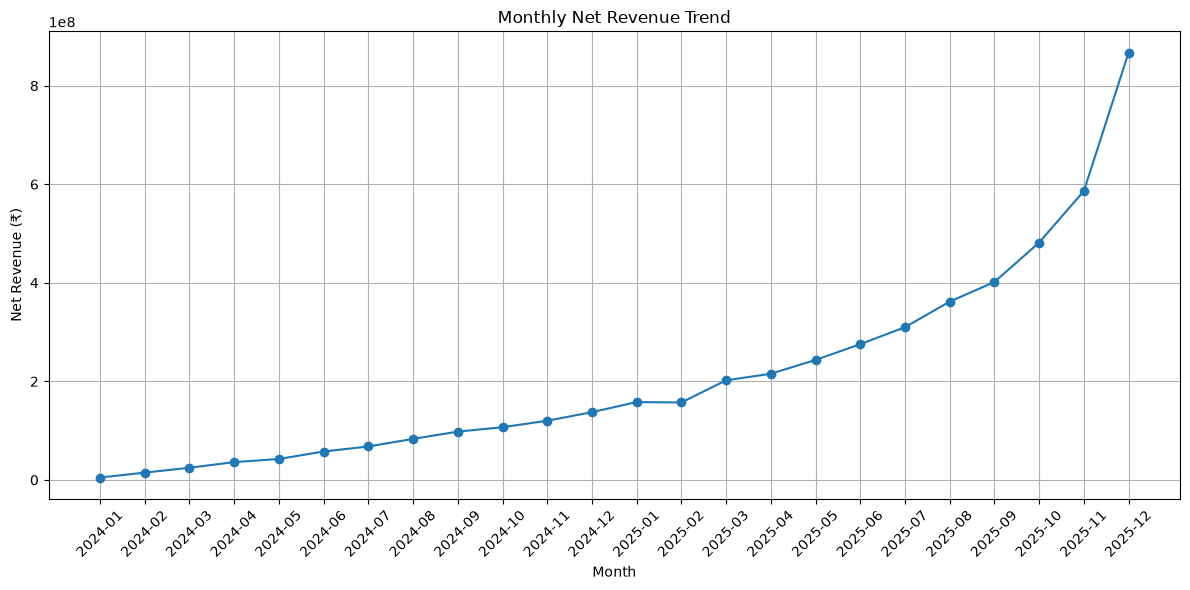

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["net_amount"],
    marker="o"
)

plt.title("Monthly Net Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

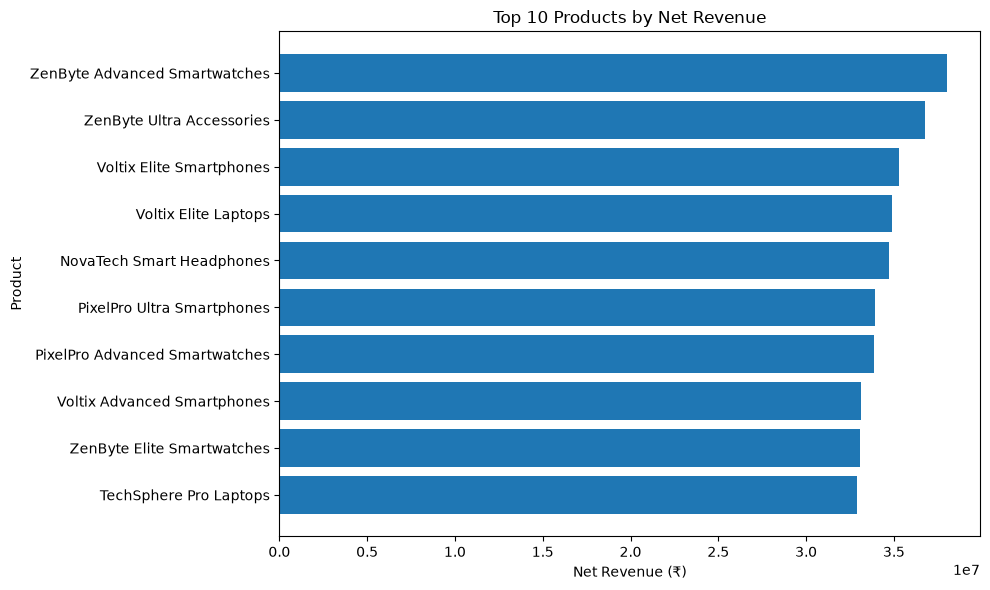

In [18]:
top10 = top_products.sort_values(
    "revenue",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["product_name"],
    top10["revenue"]
)

plt.title("Top 10 Products by Net Revenue")
plt.xlabel("Net Revenue (₹)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

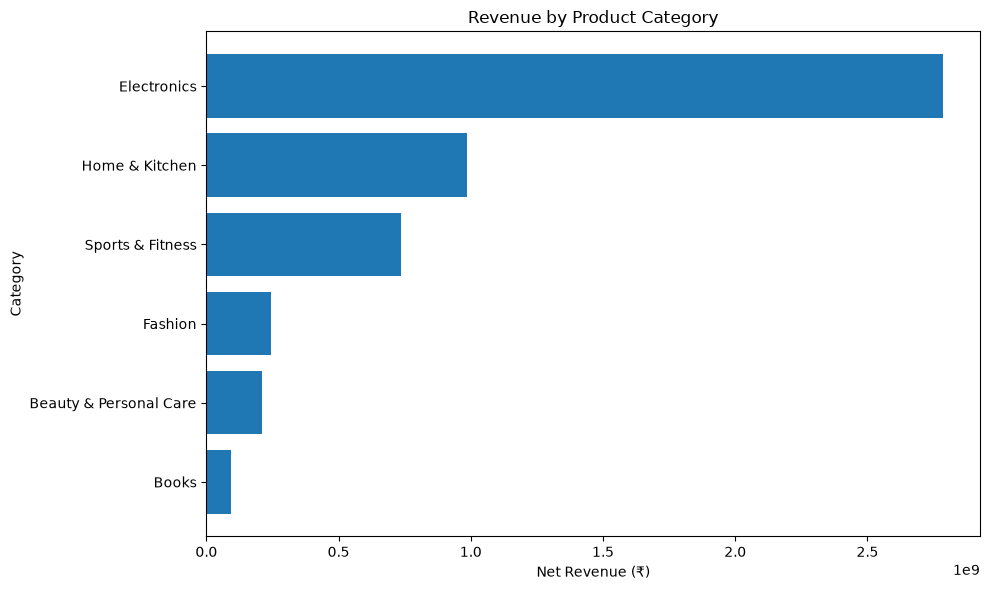

In [19]:
category_plot = category_sales.sort_values(
    "revenue",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_plot.index,
    category_plot["revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Net Revenue (₹)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

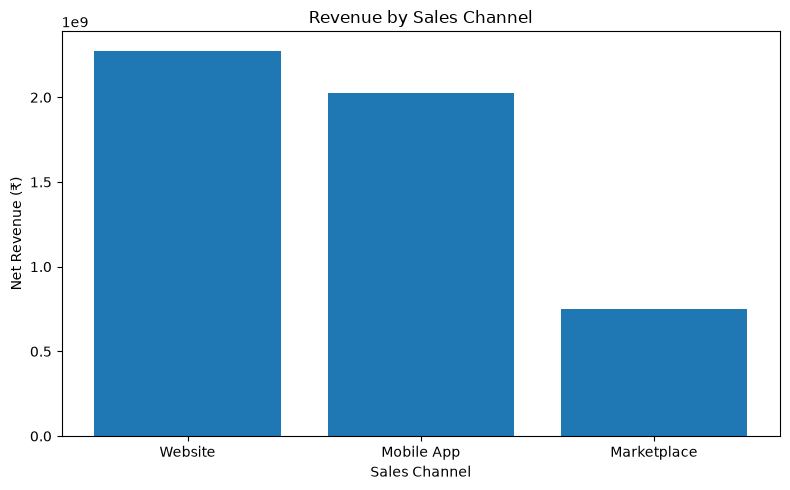

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_sales.index,
    channel_sales["revenue"]
)

plt.title("Revenue by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Net Revenue (₹)")

plt.tight_layout()
plt.show()

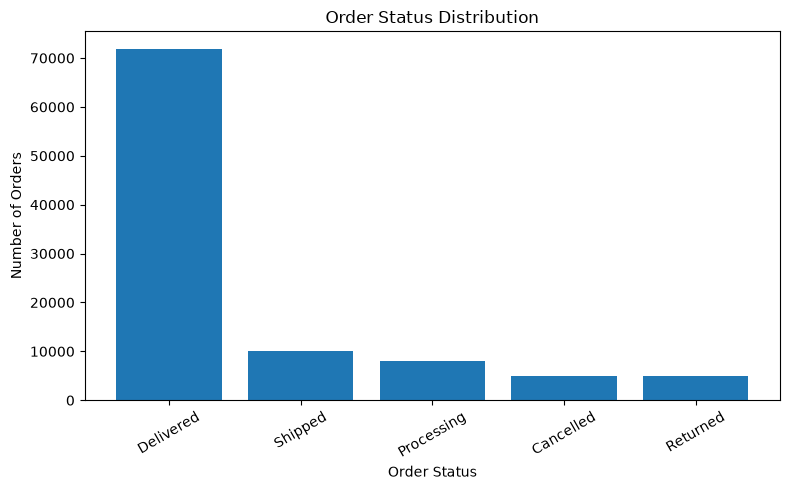

In [21]:
order_status_counts = orders["order_status"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    order_status_counts.index,
    order_status_counts.values
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

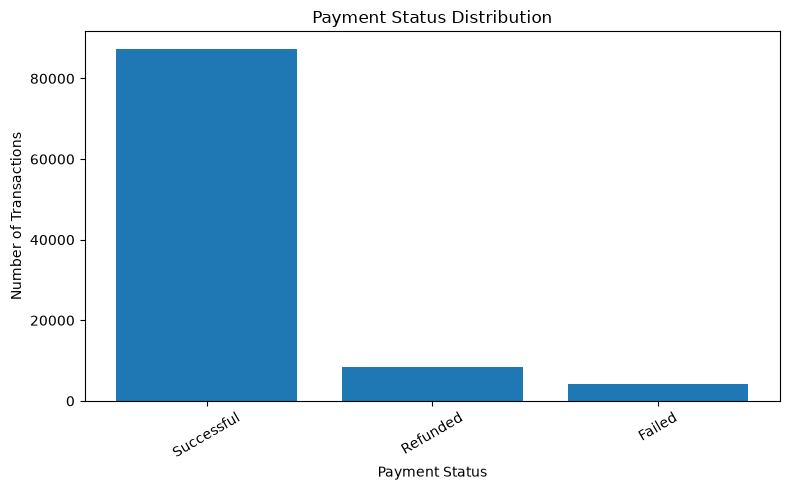

In [22]:
payment_status_counts = payments["payment_status"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    payment_status_counts.index,
    payment_status_counts.values
)

plt.title("Payment Status Distribution")
plt.xlabel("Payment Status")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [23]:
best_category = category_sales["revenue"].idxmax()
best_category_revenue = category_sales["revenue"].max()

print("Best Category:", best_category)
print(f"Revenue: ₹{best_category_revenue:,.2f}")

Best Category: Electronics
Revenue: ₹2,786,280,387.00


In [24]:
best_channel = channel_sales["revenue"].idxmax()
best_channel_revenue = channel_sales["revenue"].max()

print("Best Sales Channel:", best_channel)
print(f"Revenue: ₹{best_channel_revenue:,.2f}")

Best Sales Channel: Website
Revenue: ₹2,275,800,194.50


In [25]:
print(
    customer_sales[
        ["customer_id", "orders", "quantity_sold", "revenue"]
    ].head(10)
)

      customer_id  orders  quantity_sold    revenue
2140       C02155       6             43  1280758.0
18039      C18159       9             47  1262494.0
18271      C18392       9             50  1235714.5
10852      C10921      12             58  1184067.0
15834      C15937      13             65  1152215.5
17887      C18005      11             74  1148593.0
1697       C01709       9             59  1138679.0
13040      C13126      10             55  1133612.0
14214      C14303      12             57  1127122.5
11523      C11594       6             42  1122519.5


In [26]:
customer_orders = orders[
    ["order_id", "customer_id", "order_date"]
].copy()

customer_orders["order_date"] = pd.to_datetime(
    customer_orders["order_date"]
)

customer_orders.head()

,order_id,customer_id,order_date
0,O000001,C03649,2024-10-27
1,O000002,C04573,2025-04-28
2,O000003,C02849,2025-11-16
3,O000004,C07165,2025-03-28
4,O000005,C06516,2025-12-30


In [27]:
rfm = customer_sales.copy()

rfm = rfm[
    ["customer_id", "orders", "revenue"]
].rename(
    columns={
        "orders": "frequency",
        "revenue": "monetary"
    }
)

rfm.head()

,customer_id,frequency,monetary
2140,C02155,6,1280758.0
18039,C18159,9,1262494.0
18271,C18392,9,1235714.5
10852,C10921,12,1184067.0
15834,C15937,13,1152215.5


In [28]:
analysis_date = orders["order_date"].max() + pd.Timedelta(days=1)

recency = (
    customer_orders
    .groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

recency["recency"] = (
    analysis_date - recency["order_date"]
).dt.days

recency = recency[
    ["customer_id", "recency"]
]

rfm = rfm.merge(
    recency,
    on="customer_id",
    how="left"
)

rfm.head()

,customer_id,frequency,monetary,recency
0,C02155,6,1280758.0,106
1,C18159,9,1262494.0,73
2,C18392,9,1235714.5,36
3,C10921,12,1184067.0,35
4,C15937,13,1152215.5,36


In [29]:
analysis_date = orders["order_date"].max() + pd.Timedelta(days=1)

recency = (
    customer_orders
    .groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

recency["recency"] = (
    analysis_date - recency["order_date"]
).dt.days

recency = recency[
    ["customer_id", "recency"]
]

rfm = rfm.merge(
    recency,
    on="customer_id",
    how="left"
)

rfm.head()

,customer_id,frequency,monetary,recency_x,recency_y
0,C02155,6,1280758.0,106,106
1,C18159,9,1262494.0,73,73
2,C18392,9,1235714.5,36,36
3,C10921,12,1184067.0,35,35
4,C15937,13,1152215.5,36,36


In [33]:
print(rfm.columns.tolist())

['customer_id', 'frequency', 'monetary', 'recency_x', 'recency_y']


In [34]:
rfm.columns = rfm.columns.str.lower()
print(rfm.columns.tolist())

['customer_id', 'frequency', 'monetary', 'recency_x', 'recency_y']


In [36]:
# Fix duplicate recency columns
rfm["recency"] = rfm["recency_x"]

# Keep only the required RFM columns
rfm = rfm[["customer_id", "recency", "frequency", "monetary"]]

print(rfm.columns.tolist())

['customer_id', 'recency', 'frequency', 'monetary']


In [37]:
# ============================================
# 39. CREATE RFM SCORES
# ============================================

# Recency: lower number of days = better score
rfm["R_score"] = pd.Series(
    6 - rfm["recency"].rank(pct=True).mul(5).round().astype(int),
    index=rfm.index
).clip(1, 5)

# Frequency: higher number of purchases = better score
rfm["F_score"] = pd.Series(
    rfm["frequency"].rank(pct=True).mul(5).round().astype(int),
    index=rfm.index
).clip(1, 5)

# Monetary: higher spending = better score
rfm["M_score"] = pd.Series(
    rfm["monetary"].rank(pct=True).mul(5).round().astype(int),
    index=rfm.index
).clip(1, 5)

# Combined RFM score
rfm["RFM_score"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)

# Display result
print("RFM Scores Created Successfully!")
print()
print(
    rfm[
        ["customer_id", "recency", "frequency", "monetary",
         "R_score", "F_score", "M_score", "RFM_score"]
    ].head(10)
)

RFM Scores Created Successfully!

  customer_id  recency  frequency   monetary  R_score  F_score  M_score  \
0      C02155      106          6  1280758.0        2        3        5   
1      C18159       73          9  1262494.0        3        5        5   
2      C18392       36          9  1235714.5        4        5        5   
3      C10921       35         12  1184067.0        4        5        5   
4      C15937       36         13  1152215.5        4        5        5   
5      C18005       28         11  1148593.0        4        5        5   
6      C01709       72          9  1138679.0        3        5        5   
7      C13126       18         10  1133612.0        4        5        5   
8      C14303       22         12  1127122.5        4        5        5   
9      C11594       43          6  1122519.5        3        3        5   

   RFM_score  
0         10  
1         13  
2         14  
3         14  
4         14  
5         14  
6         13  
7         14  
8    

In [38]:
# ============================================
# 40. CREATE CUSTOMER SEGMENTS
# ============================================

def segment_customer(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Customers"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost Customers"


rfm["customer_segment"] = rfm["RFM_score"].apply(segment_customer)

print("Customer Segments Created Successfully!")
print()

print(rfm[
    ["customer_id", "RFM_score", "customer_segment"]
].head(10))

print("\nSegment Distribution:")
print(rfm["customer_segment"].value_counts())

Customer Segments Created Successfully!

  customer_id  RFM_score customer_segment
0      C02155         10  Loyal Customers
1      C18159         13        Champions
2      C18392         14        Champions
3      C10921         14        Champions
4      C15937         14        Champions
5      C18005         14        Champions
6      C01709         13        Champions
7      C13126         14        Champions
8      C14303         14        Champions
9      C11594         11  Loyal Customers

Segment Distribution:
customer_segment
Potential Customers    6824
Loyal Customers        5782
At Risk                4292
Champions              2135
Lost Customers          830
Name: count, dtype: int64


In [39]:
# ============================================
# 41. CUSTOMER SEGMENT ANALYSIS
# ============================================

segment_summary = (
    rfm.groupby("customer_segment")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_rfm_score=("RFM_score", "mean")
    )
    .round(2)
    .sort_values("avg_rfm_score", ascending=False)
)

print("CUSTOMER SEGMENT ANALYSIS")
print("=" * 50)
print(segment_summary)

CUSTOMER SEGMENT ANALYSIS
                     customers  avg_recency  avg_frequency  avg_monetary  \
customer_segment                                                           
Champions                 2135        13.82           8.45     515686.46   
Loyal Customers           5782        33.65           6.27     342214.44   
Potential Customers       6824        61.05           4.55     205599.38   
At Risk                   4292       120.79           3.03     120144.28   
Lost Customers             830       304.66           1.99      66243.77   

                     avg_rfm_score  
customer_segment                    
Champions                    13.62  
Loyal Customers              10.90  
Potential Customers           8.01  
At Risk                       5.10  
Lost Customers                3.00  


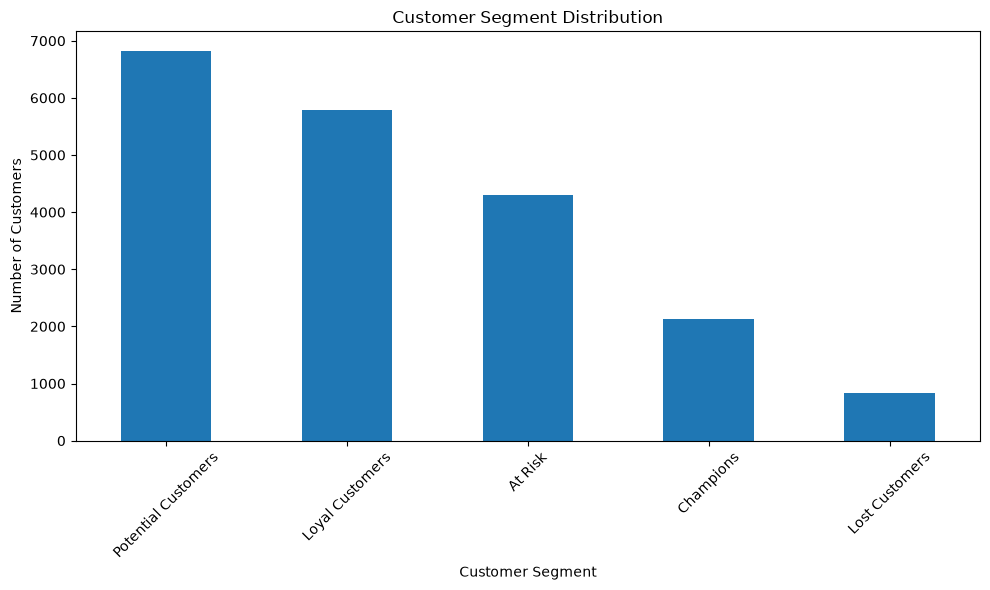

In [40]:
# ============================================
# 42. CUSTOMER SEGMENT VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

segment_counts = rfm["customer_segment"].value_counts()

plt.figure(figsize=(10, 6))
segment_counts.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# ============================================
# 43. TOP 10 CUSTOMERS BY REVENUE
# ============================================

top_customers = (
    rfm[
        ["customer_id", "frequency", "monetary",
         "RFM_score", "customer_segment"]
    ]
    .sort_values("monetary", ascending=False)
    .head(10)
)

print("TOP 10 CUSTOMERS BY REVENUE")
print("=" * 60)
print(top_customers.to_string(index=False))

TOP 10 CUSTOMERS BY REVENUE
customer_id  frequency  monetary  RFM_score customer_segment
     C02155          6 1280758.0         10  Loyal Customers
     C18159          9 1262494.0         13        Champions
     C18392          9 1235714.5         14        Champions
     C10921         12 1184067.0         14        Champions
     C15937         13 1152215.5         14        Champions
     C18005         11 1148593.0         14        Champions
     C01709          9 1138679.0         13        Champions
     C13126         10 1133612.0         14        Champions
     C14303         12 1127122.5         14        Champions
     C11594          6 1122519.5         11  Loyal Customers


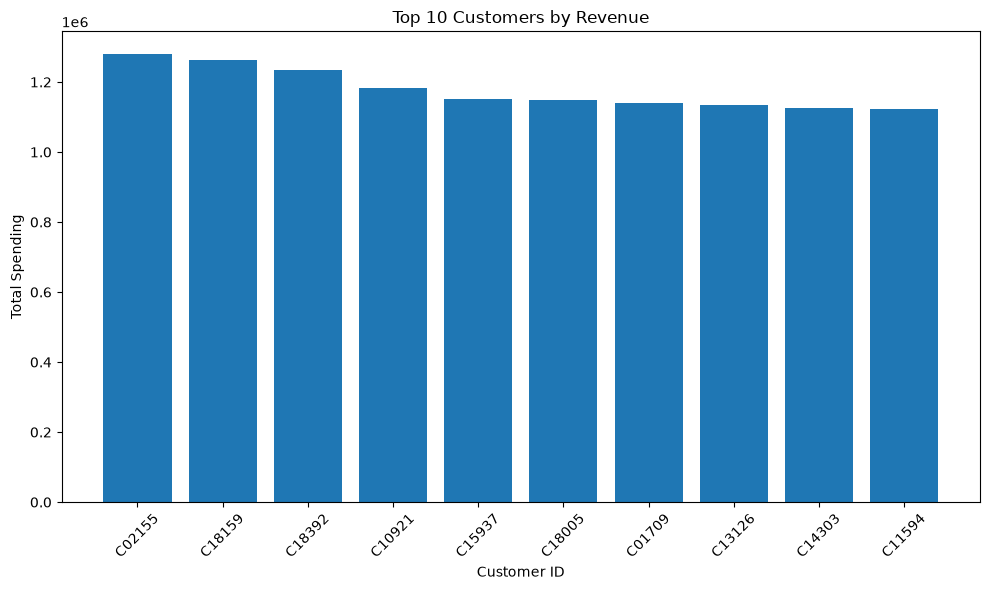

In [42]:
# ============================================
# 44. TOP 10 CUSTOMERS VISUALIZATION
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    top_customers["customer_id"].astype(str),
    top_customers["monetary"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

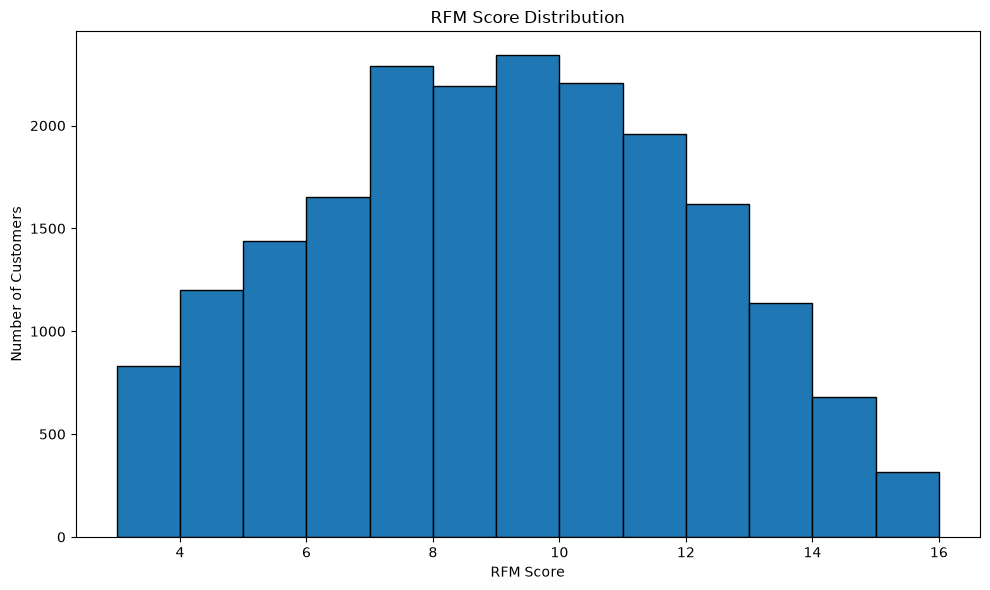

In [43]:
# ============================================
# 45. RFM SCORE DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 6))

plt.hist(
    rfm["RFM_score"],
    bins=range(
        int(rfm["RFM_score"].min()),
        int(rfm["RFM_score"].max()) + 2
    ),
    edgecolor="black"
)

plt.title("RFM Score Distribution")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [44]:
# ============================================
# 46. PRODUCT PERFORMANCE ANALYSIS
# ============================================

product_analysis = (
    order_items
    .groupby("product_id")
    .agg(
        units_sold=("quantity", "sum"),
        gross_revenue=("gross_amount", "sum"),
        discount_amount=("discount_amount", "sum"),
        net_revenue=("net_amount", "sum"),
        average_discount=("discount_pct", "mean")
    )
    .reset_index()
)

product_analysis = product_analysis.merge(
    products[
        ["product_id", "product_name", "category", "brand"]
    ],
    on="product_id",
    how="left"
)

print("Product analytical table created!")
print(product_analysis.head())

Product analytical table created!
  product_id  units_sold  gross_revenue  discount_amount  net_revenue  \
0     P00001         429       471900.0          37510.0     434390.0   
1     P00002         515       942450.0          78964.5     863485.5   
2     P00003         438      2960880.0         248768.0    2712112.0   
3     P00004         412      2855160.0         227650.5    2627509.5   
4     P00005         456       337440.0          26603.0     310837.0   

   average_discount                     product_name          category  \
0          8.153310     KnowledgeHouse Ultra Fiction             Books   
1          8.277439  KnowledgeHouse Modern Self Help             Books   
2          8.152542      FitCore Everyday Sportswear  Sports & Fitness   
3          7.989130         TrendRoot Ultra Trousers           Fashion   
4          8.153595          ReadMore Ultra Business             Books   

            brand  
0  KnowledgeHouse  
1  KnowledgeHouse  
2         FitCore  
3 

In [45]:
# ============================================
# 47. TOP PRODUCTS BY UNITS SOLD
# ============================================

top_products_quantity = (
    product_analysis
    .sort_values("units_sold", ascending=False)
    .head(10)
)

print("TOP 10 PRODUCTS BY UNITS SOLD")
print("=" * 60)

print(
    top_products_quantity[
        [
            "product_name",
            "category",
            "units_sold",
            "net_revenue"
        ]
    ].to_string(index=False)
)

TOP 10 PRODUCTS BY UNITS SOLD
                       product_name               category  units_sold  net_revenue
      KitchenPro Classic Home Decor         Home & Kitchen         540     844730.0
               ActivePro Ultra Yoga       Sports & Fitness         535    6166368.0
          ZenByte Ultra Accessories            Electronics         529   36758592.5
      LearnPress Modern Non-Fiction                  Books         529     648175.5
              RunX Advanced Running       Sports & Fitness         526    6597265.5
         CasaLiving Ultra Furniture         Home & Kitchen         525     896047.5
        FlexFit Elite Gym Equipment       Sports & Fitness         525    5505317.5
       BloomCare Classic Fragrances Beauty & Personal Care         522      85725.0
UrbanHome Modern Kitchen Appliances         Home & Kitchen         522   10208502.5
     GlowPure Premium Personal Care Beauty & Personal Care         521    1616530.0


In [46]:
# ============================================
# 48. CATEGORY PERFORMANCE
# ============================================

category_analysis = (
    product_analysis
    .groupby("category")
    .agg(
        products=("product_id", "nunique"),
        units_sold=("units_sold", "sum"),
        gross_revenue=("gross_revenue", "sum"),
        discount_amount=("discount_amount", "sum"),
        net_revenue=("net_revenue", "sum")
    )
    .sort_values("net_revenue", ascending=False)
)

print(category_analysis)

                        products  units_sold  gross_revenue  discount_amount  \
category                                                                       
Electronics                  162       73042   3.031106e+09      244825753.0   
Home & Kitchen               175       79105   1.072664e+09       87897894.5   
Sports & Fitness             176       80393   8.013420e+08       65944887.0   
Fashion                      145       65322   2.672473e+08       21726656.5   
Beauty & Personal Care       173       79139   2.276403e+08       18588954.5   
Books                        169       76791   1.005193e+08        8208287.5   

                         net_revenue  
category                              
Electronics             2.786280e+09  
Home & Kitchen          9.847658e+08  
Sports & Fitness        7.353971e+08  
Fashion                 2.455206e+08  
Beauty & Personal Care  2.090514e+08  
Books                   9.231105e+07  


In [47]:
# ============================================
# 49. CATEGORY REVENUE CONTRIBUTION
# ============================================

category_analysis["revenue_share_pct"] = (
    category_analysis["net_revenue"]
    / category_analysis["net_revenue"].sum()
    * 100
).round(2)

print(
    category_analysis[
        ["products", "units_sold", "net_revenue", "revenue_share_pct"]
    ]
)

                        products  units_sold   net_revenue  revenue_share_pct
category                                                                     
Electronics                  162       73042  2.786280e+09              55.14
Home & Kitchen               175       79105  9.847658e+08              19.49
Sports & Fitness             176       80393  7.353971e+08              14.55
Fashion                      145       65322  2.455206e+08               4.86
Beauty & Personal Care       173       79139  2.090514e+08               4.14
Books                        169       76791  9.231105e+07               1.83


In [48]:
# ============================================
# 50. BRAND PERFORMANCE
# ============================================

brand_analysis = (
    product_analysis
    .groupby("brand")
    .agg(
        products=("product_id", "nunique"),
        units_sold=("units_sold", "sum"),
        net_revenue=("net_revenue", "sum")
    )
    .sort_values("net_revenue", ascending=False)
)

print("TOP 15 BRANDS BY REVENUE")
print("=" * 60)

print(brand_analysis.head(15))

TOP 15 BRANDS BY REVENUE
              products  units_sold  net_revenue
brand                                          
ZenByte             34       15398  657802844.0
Voltix              30       13260  520696206.0
PixelPro            26       11816  434957969.0
NovaTech            28       12876  433830807.5
TechSphere          22        9930  422369718.0
Auralink            22        9762  316622842.5
UrbanHome           42       19042  250920999.5
KitchenPro          36       16232  213617175.5
CasaLiving          35       16048  198295585.5
HomeNest            36       16089  183952203.5
RunX                46       21063  170926440.0
FitCore             38       17139  164783061.0
ActivePro           29       13458  141575110.5
ComfortCraft        26       11694  137979791.5
SportEdge           31       14246  133253094.0


In [49]:
# ============================================
# 51. MONTHLY ORDER TREND
# ============================================

monthly_orders = (
    orders
    .assign(
        month=orders["order_date"].dt.to_period("M")
    )
    .groupby("month")["order_id"]
    .nunique()
    .reset_index(name="orders")
)

monthly_orders["month"] = monthly_orders["month"].astype(str)

print(monthly_orders)

      month  orders
0   2024-01     101
1   2024-02     284
2   2024-03     478
3   2024-04     675
4   2024-05     900
5   2024-06    1076
6   2024-07    1341
7   2024-08    1624
8   2024-09    1881
9   2024-10    2130
10  2024-11    2346
11  2024-12    2787
12  2025-01    3154
13  2025-02    3159
14  2025-03    3960
15  2025-04    4236
16  2025-05    4847
17  2025-06    5466
18  2025-07    6129
19  2025-08    7038
20  2025-09    7913
21  2025-10    9640
22  2025-11   11630
23  2025-12   17205


In [50]:
# ============================================
# 52. MONTHLY ACTIVE CUSTOMERS
# ============================================

monthly_customers = (
    orders
    .assign(
        month=orders["order_date"].dt.to_period("M")
    )
    .groupby("month")["customer_id"]
    .nunique()
    .reset_index(name="active_customers")
)

monthly_customers["month"] = monthly_customers["month"].astype(str)

print(monthly_customers)

      month  active_customers
0   2024-01                89
1   2024-02               266
2   2024-03               432
3   2024-04               613
4   2024-05               802
5   2024-06               965
6   2024-07              1193
7   2024-08              1414
8   2024-09              1653
9   2024-10              1884
10  2024-11              2056
11  2024-12              2393
12  2025-01              2704
13  2025-02              2776
14  2025-03              3405
15  2025-04              3613
16  2025-05              4041
17  2025-06              4503
18  2025-07              4954
19  2025-08              5458
20  2025-09              5992
21  2025-10              6911
22  2025-11              7751
23  2025-12              8691


In [51]:
# ============================================
# 53. MONTHLY AVERAGE ORDER VALUE
# ============================================

monthly_aov = monthly_revenue.merge(
    monthly_orders,
    on="month"
)

monthly_aov["AOV"] = (
    monthly_aov["net_amount"]
    / monthly_aov["orders"]
)

print(
    monthly_aov[
        ["month", "net_amount", "orders", "AOV"]
    ]
)

      month   net_amount  orders           AOV
0   2024-01    4641715.5     101  45957.579208
1   2024-02   14761870.0     284  51978.415493
2   2024-03   24591809.0     478  51447.299163
3   2024-04   36060049.0     675  53422.294815
4   2024-05   42423134.5     900  47136.816111
5   2024-06   57602367.0    1076  53533.798327
6   2024-07   67806903.5    1341  50564.432140
7   2024-08   83196670.5    1624  51229.476909
8   2024-09   97983192.0    1881  52091.011164
9   2024-10  106871623.0    2130  50174.470892
10  2024-11  120017938.0    2346  51158.541347
11  2024-12  137410058.0    2787  49303.931826
12  2025-01  157956004.0    3154  50081.168041
13  2025-02  157080749.5    3159  49724.833650
14  2025-03  202105843.5    3960  51036.829167
15  2025-04  215390161.5    4236  50847.535765
16  2025-05  243467780.5    4847  50230.612853
17  2025-06  275480030.0    5466  50398.834614
18  2025-07  309825646.5    6129  50550.766275
19  2025-08  361827502.5    7038  51410.557332
20  2025-09  

In [52]:
# ============================================
# 54. SAVE EDA OUTPUTS
# ============================================

OUTPUT_PATH = Path("../data/processed/eda_outputs")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

product_analysis.to_csv(
    OUTPUT_PATH / "product_analysis.csv",
    index=False
)

category_analysis.to_csv(
    OUTPUT_PATH / "category_analysis.csv"
)

brand_analysis.to_csv(
    OUTPUT_PATH / "brand_analysis.csv"
)

monthly_revenue.to_csv(
    OUTPUT_PATH / "monthly_revenue.csv",
    index=False
)

monthly_orders.to_csv(
    OUTPUT_PATH / "monthly_orders.csv",
    index=False
)

monthly_customers.to_csv(
    OUTPUT_PATH / "monthly_customers.csv",
    index=False
)

monthly_aov.to_csv(
    OUTPUT_PATH / "monthly_aov.csv",
    index=False
)

rfm.to_csv(
    OUTPUT_PATH / "customer_rfm.csv",
    index=False
)

print("EDA outputs saved successfully!")

EDA outputs saved successfully!


In [53]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nPRODUCTS")
print(products.columns.tolist())

print("\nORDERS")
print(orders.columns.tolist())

print("\nORDER ITEMS")
print(order_items.columns.tolist())

print("\nPAYMENTS")
print(payments.columns.tolist())

CUSTOMERS
['customer_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'city', 'state', 'pincode', 'signup_date', 'customer_type']

PRODUCTS
['product_id', 'product_name', 'category', 'subcategory', 'brand', 'selling_price', 'cost_price', 'stock_quantity', 'rating', 'launch_date']

ORDERS
['order_id', 'customer_id', 'order_date', 'order_status', 'sales_channel']

ORDER ITEMS
['order_id', 'product_id', 'quantity', 'unit_price', 'discount_pct', 'gross_amount', 'discount_amount', 'net_amount', 'order_date']

PAYMENTS
['payment_id', 'order_id', 'payment_date', 'payment_method', 'payment_status', 'payment_amount']


In [54]:
# ============================================
# SHOPSPHERE - COMPLETE COLUMN CHECK
# ============================================

for name, df in {
    "CUSTOMERS": customers,
    "PRODUCTS": products,
    "ORDERS": orders,
    "ORDER_ITEMS": order_items,
    "PAYMENTS": payments
}.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    for column in df.columns:
        print(f"{column} -> {df[column].dtype}")


CUSTOMERS
customer_id -> str
first_name -> str
last_name -> str
gender -> str
date_of_birth -> str
city -> str
state -> str
pincode -> int64
signup_date -> str
customer_type -> str

PRODUCTS
product_id -> str
product_name -> str
category -> str
subcategory -> str
brand -> str
selling_price -> int64
cost_price -> int64
stock_quantity -> int64
rating -> float64
launch_date -> str

ORDERS
order_id -> str
customer_id -> str
order_date -> datetime64[us]
order_status -> str
sales_channel -> str

ORDER_ITEMS
order_id -> str
product_id -> str
quantity -> int64
unit_price -> float64
discount_pct -> int64
gross_amount -> float64
discount_amount -> float64
net_amount -> float64
order_date -> datetime64[us]

PAYMENTS
payment_id -> str
order_id -> str
payment_date -> datetime64[us]
payment_method -> str
payment_status -> str
payment_amount -> float64


NameError: name 'customers' is not defined

In [4]:

import pandas as pd

customers = pd.read_csv(
    r"C:\Users\hp\Desktop\ShopSphere\data\processed\customers_clean.csv"
)

print(customers.shape)
print(customers.columns)}

SyntaxError: unmatched '}' (886249173.py, line 8)

In [5]:
import pandas as pd

customers = pd.read_csv(
    r"C:\Users\hp\Desktop\ShopSphere\data\processed\customers_clean.csv"
)

print(customers.shape)
print(customers.columns)

(20000, 10)
Index(['customer_id', 'first_name', 'last_name', 'gender', 'date_of_birth',
       'city', 'state', 'pincode', 'signup_date', 'customer_type'],
      dtype='str')


In [6]:
print(customers.shape)
print(customers.columns)


(20000, 10)
Index(['customer_id', 'first_name', 'last_name', 'gender', 'date_of_birth',
       'city', 'state', 'pincode', 'signup_date', 'customer_type'],
      dtype='str')
